# Advisor review â€” empirical visualization

Visualizes the four advisor-feedback follow-up experiments living under
`results/advisor_review/`. Built incrementally â€” each section corresponds
to one Step in the worker plan and is gated on those CSVs existing on
disk, so this notebook is safe to re-run at any stage of the experiments.

Sections
1. **Setup** â€” paths, loaders, styling.
2. **HP tuning summary** â€” Pareto scatters per HP sweep step.
3. **Hypothesis 3a: DP vs AP** (healthcare).
4. **Hypothesis 3b: benefit vs cost imbalance** (MD).
5. **Hypothesis 3c: train vs test gap** (healthcare).
6. **Budget tightness sweep** (MD + healthcare side by side).
7. **Takeaways**.

## 1. Setup

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path('..').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from experiments.configs import COLOR_MAP, MARKER_MAP

ADV = REPO_ROOT / 'results' / 'advisor_review'
FIGS = ADV / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

print('repo root:', REPO_ROOT)
print('advisor results dir:', ADV)
print('exists:', ADV.exists())

repo root: E:\Codes\DecisionFocusedMTL
advisor results dir: E:\Codes\DecisionFocusedMTL\results\advisor_review
exists: True


In [2]:
def load_run(run_dir: Path) -> tuple[pd.DataFrame, dict]:
    """Load (stage_df, config_payload) from a single advisor_review run dir."""
    run_dir = Path(run_dir)
    stage_csv = run_dir / 'stage_results.csv'
    cfg_json = run_dir / 'config.json'
    if not stage_csv.exists():
        return pd.DataFrame(), {}
    df = pd.read_csv(stage_csv)
    cfg = json.loads(cfg_json.read_text()) if cfg_json.exists() else {}
    df['_source_dir'] = str(run_dir.relative_to(ADV))
    return df, cfg


def load_many(parent: Path, glob: str = '*') -> pd.DataFrame:
    """Concatenate stage_results.csv across all subdirectories matching `glob`."""
    dfs = []
    for sub in sorted(Path(parent).glob(glob)):
        if not sub.is_dir():
            continue
        df, _ = load_run(sub)
        if not df.empty:
            df['_subdir'] = sub.name
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


def style_for(method: str) -> dict:
    return {
        'color': COLOR_MAP.get(method, '#888888'),
        'marker': MARKER_MAP.get(method, 'o'),
    }


def savefig(fig: plt.Figure, name: str, dpi: int = 130) -> Path:
    out = FIGS / name
    fig.savefig(out, dpi=dpi, bbox_inches='tight')
    print('  saved', out)
    return out

In [3]:
# Smoke-test the loader on the existing smoke_test run.
smoke = ADV / 'hp_tuning' / 'md_knapsack' / 'smoke_test'
df_smoke, cfg_smoke = load_run(smoke)
print('smoke rows:', len(df_smoke))
if len(df_smoke):
    cols = ['method', 'lambda', 'train_regret', 'test_regret',
            'train_pred_mse', 'test_pred_mse', 'train_fairness', 'test_fairness']
    print(df_smoke[cols].to_string(index=False))

smoke rows: 2
method  lambda  train_regret  test_regret  train_pred_mse  test_pred_mse  train_fairness  test_fairness
  fpto     0.0    429.317887   167.986787        4.242714       3.860375        0.085232       1.735677
   dfl     0.0    244.644849   116.251382        4.091484       3.828516        0.103539       1.797463


C:\Users\14469\AppData\Local\Temp\ipykernel_9740\3797103930.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['_source_dir'] = str(run_dir.relative_to(ADV))


## 2. HP tuning summary (Step 2)

One Pareto scatter per sweep stage. The goal of HP tuning is to find a
configuration where method families *separate*: PTO/SAA cluster at low
MSE / high regret, DFL/FDFL at higher MSE / lower regret, MOO methods
in between. We are NOT minimising any single number.

This cell is gated â€” it only runs once the HP sweep dirs exist.

In [4]:
hp_root = ADV / 'hp_tuning' / 'md_knapsack'
hp_subdirs = [p for p in sorted(hp_root.iterdir()) if p.is_dir() and p.name != 'figures']
print('HP sweep stages found:', [p.name for p in hp_subdirs])

HP sweep stages found: ['smoke_test', 'spsa_smoke', 'spsa_smoke_dirs4', 'spsa_tune', 'sweep01_pipeline_check', 'sweep02_snr', 'sweep03_budget', 'sweep04_hidden', 'sweep05_chosen_config']


C:\Users\14469\AppData\Local\Temp\ipykernel_9740\3797103930.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['_source_dir'] = str(run_dir.relative_to(ADV))
C:\Users\14469\AppData\Local\Temp\ipykernel_9740\3797103930.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['_source_dir'] = str(run_dir.relative_to(ADV))
C:\Users\14469\AppData\Local\Temp\ipykernel_9740\3797103930.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performa

  saved E:\Codes\DecisionFocusedMTL\results\advisor_review\figures\hp_sweep_pareto_overview.png


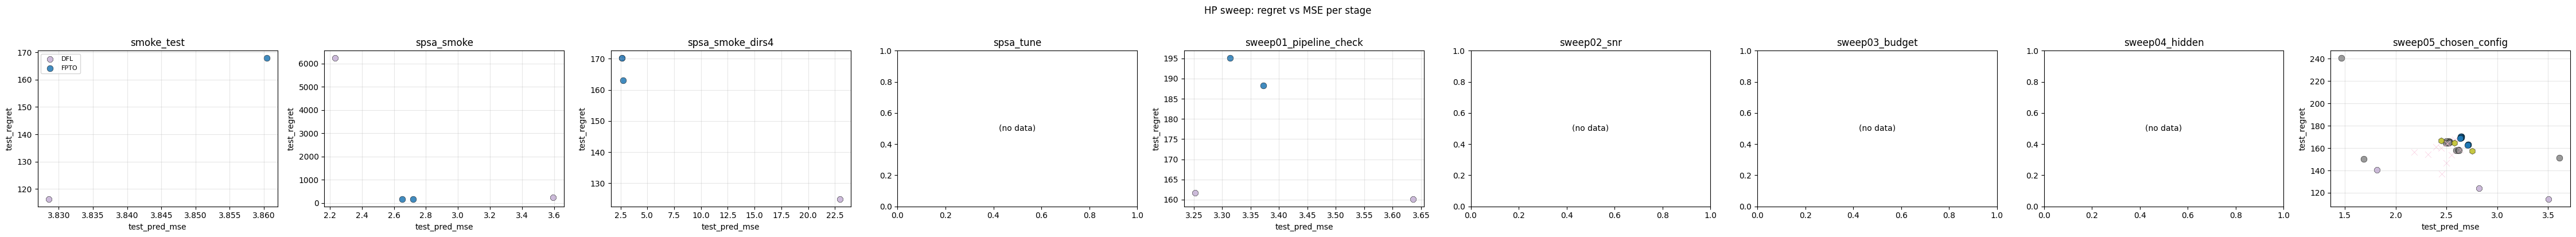

In [5]:
def pareto_scatter(df: pd.DataFrame, ax: plt.Axes, x: str, y: str, title: str = '') -> None:
    if df.empty or x not in df or y not in df:
        ax.text(0.5, 0.5, '(no data)', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return
    for method, sub in df.groupby('method'):
        s = style_for(str(method).upper())
        ax.scatter(sub[x], sub[y], label=str(method).upper(), **s, s=60, alpha=0.85, edgecolor='black', linewidth=0.4)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)


if hp_subdirs:
    n = len(hp_subdirs)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), squeeze=False)
    for ax, sub in zip(axes[0], hp_subdirs):
        df, _ = load_run(sub)
        pareto_scatter(df, ax, x='test_pred_mse', y='test_regret', title=sub.name)
    axes[0, 0].legend(loc='best', fontsize=8)
    fig.suptitle('HP sweep: regret vs MSE per stage', y=1.02)
    fig.tight_layout()
    savefig(fig, 'hp_sweep_pareto_overview.png')
    plt.show()
else:
    print('(no HP sweep dirs yet â€” run Step 2)')

## 3. Hypothesis 3a â€” Demographic parity vs Accuracy parity (healthcare)

Side-by-side Pareto plots: regret-vs-fairness for `mad` (accuracy parity)
and `dp` (demographic parity). One panel per alpha.

In [6]:
# AP results live under .../mad/ (the fairness_type used at run time);
# DP results live under .../dp/. Each subdirectory holds alpha_*/ runs.
ap_root = ADV / 'hypothesis' / 'dp_vs_ap' / 'mad'
dp_root = ADV / 'hypothesis' / 'dp_vs_ap' / 'dp'


def load_alphas(root: Path) -> pd.DataFrame:
    if not root.exists():
        return pd.DataFrame()
    rows = []
    for sub in sorted(root.iterdir()):
        if not sub.is_dir():
            continue
        df, cfg = load_run(sub)
        if not df.empty:
            df['alpha_fair'] = cfg.get('task_cfg', {}).get('alpha_fair', np.nan)
            rows.append(df)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


df_ap = load_alphas(ap_root)
df_dp = load_alphas(dp_root)
print('AP rows:', len(df_ap), '  DP rows:', len(df_dp))
if not df_ap.empty:
    print('AP alphas:', sorted(df_ap['alpha_fair'].unique()))


AP rows: 170   DP rows: 170
AP alphas: [np.float64(0.5), np.float64(2.0)]


  saved E:\Codes\DecisionFocusedMTL\results\advisor_review\figures\pareto_dp_vs_ap_regret_vs_fairness.png


C:\Users\14469\AppData\Local\Temp\ipykernel_9740\1997746881.py:10: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(mdf[x], mdf[y], color=s['color'], marker=mk,


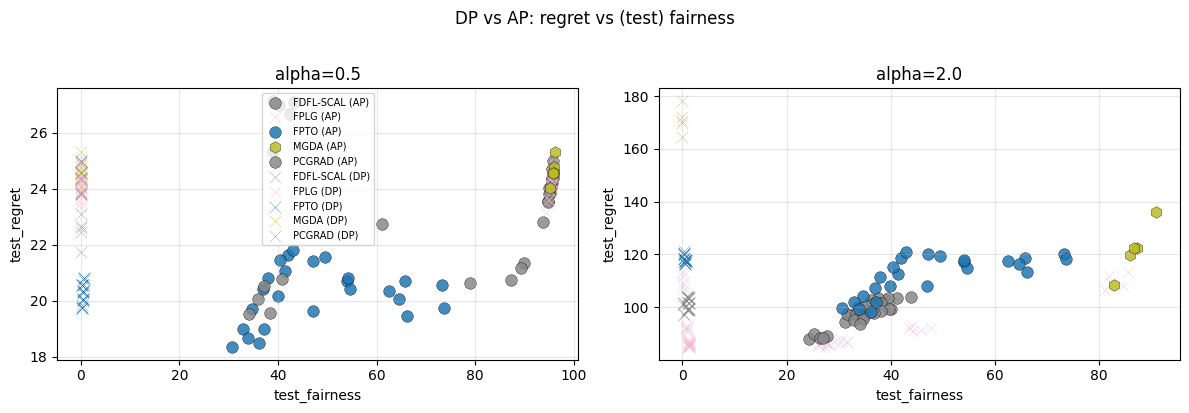

In [7]:
def overlay_pareto(df_a: pd.DataFrame, df_b: pd.DataFrame, label_a: str, label_b: str,
                   x: str, y: str, alpha: float, ax: plt.Axes) -> None:
    for df, label, marker_offset in ((df_a, label_a, 0), (df_b, label_b, 1)):
        if df.empty or 'alpha_fair' not in df:
            continue
        sub = df[df.get('alpha_fair', alpha) == alpha]
        for method, mdf in sub.groupby('method'):
            s = style_for(str(method).upper())
            mk = s['marker'] if marker_offset == 0 else 'x'
            ax.scatter(mdf[x], mdf[y], color=s['color'], marker=mk,
                       label=f"{method.upper()} ({label})",
                       s=70, alpha=0.85, edgecolor='black', linewidth=0.3)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'alpha={alpha}')
    ax.grid(True, alpha=0.3)


if not df_ap.empty or not df_dp.empty:
    alphas = sorted(set(df_ap.get('alpha_fair', [])).union(df_dp.get('alpha_fair', [])))
    if alphas:
        fig, axes = plt.subplots(1, len(alphas), figsize=(6 * len(alphas), 4), squeeze=False)
        for ax, a in zip(axes[0], alphas):
            overlay_pareto(df_ap, df_dp, 'AP', 'DP', x='test_fairness', y='test_regret', alpha=a, ax=ax)
        axes[0, 0].legend(fontsize=7, loc='best')
        fig.suptitle('DP vs AP: regret vs (test) fairness', y=1.02)
        fig.tight_layout()
        savefig(fig, 'pareto_dp_vs_ap_regret_vs_fairness.png')
        plt.show()
else:
    print('(no DP/AP runs yet â€” run Step 3a)')

## 4. Hypothesis 3b â€” Benefit vs cost imbalance (MD)

3Ã—3 grid of `(benefit_group_bias, cost_group_bias)` cells.
Render two heatmaps per method: test_regret and test_fairness.

In [8]:
bc_root = ADV / 'hypothesis' / 'benefit_cost_imbalance'
bc_dirs = sorted([p for p in bc_root.iterdir() if p.is_dir()]) if bc_root.exists() else []
print('benefit/cost cells found:', len(bc_dirs))

benefit/cost cells found: 8


C:\Users\14469\AppData\Local\Temp\ipykernel_9740\3797103930.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['_source_dir'] = str(run_dir.relative_to(ADV))
C:\Users\14469\AppData\Local\Temp\ipykernel_9740\210152574.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['_bb'] = bb


  saved E:\Codes\DecisionFocusedMTL\results\advisor_review\figures\imbalance_grid_test_regret.png


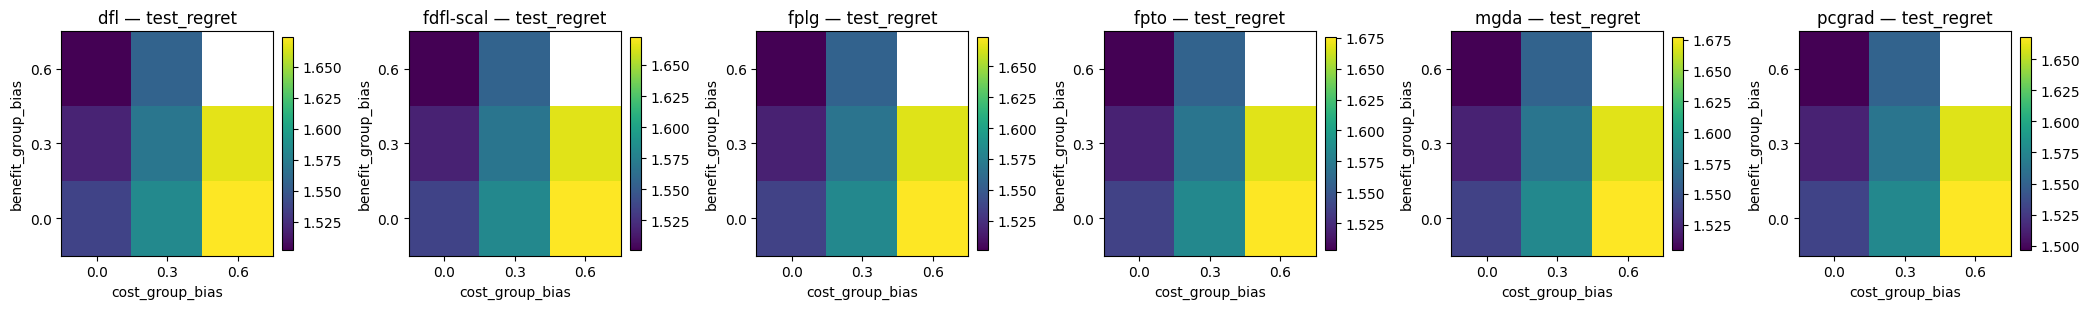

  saved E:\Codes\DecisionFocusedMTL\results\advisor_review\figures\imbalance_grid_test_fairness.png


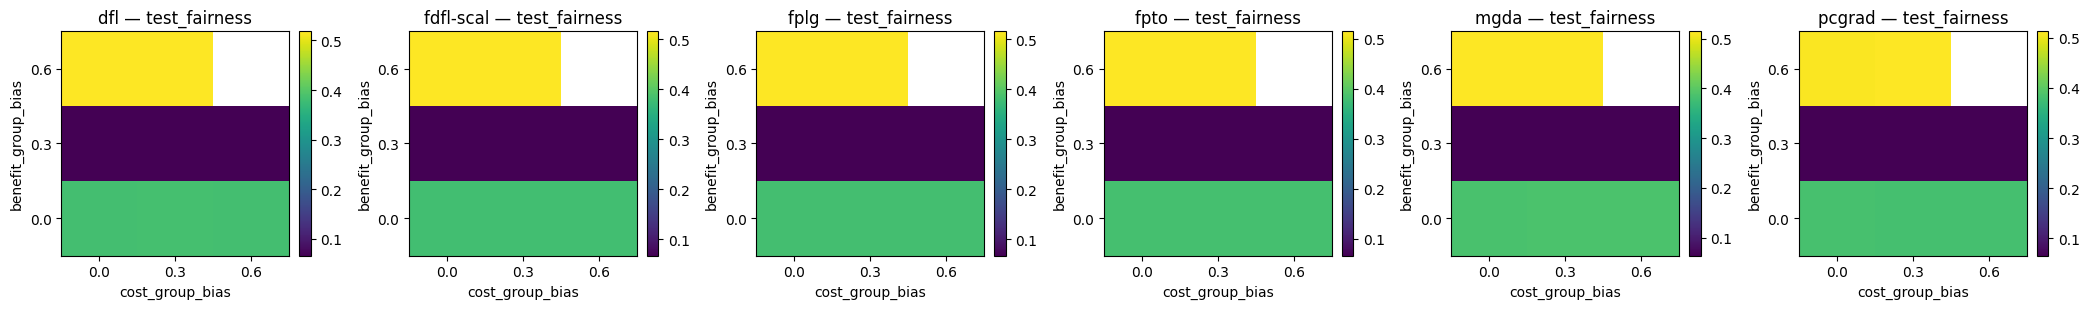

In [9]:
if bc_dirs:
    rows = []
    for d in bc_dirs:
        df, cfg = load_run(d)
        if df.empty:
            continue
        bb = cfg.get('task_cfg', {}).get('benefit_group_bias', None)
        cb = cfg.get('task_cfg', {}).get('cost_group_bias', None)
        df['_bb'] = bb
        df['_cb'] = cb
        rows.append(df)
    grid_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    if not grid_df.empty:
        for metric in ('test_regret', 'test_fairness'):
            methods = sorted(grid_df['method'].unique())
            n = len(methods)
            fig, axes = plt.subplots(1, n, figsize=(3.5 * n, 3.2), squeeze=False)
            for ax, m in zip(axes[0], methods):
                pivot = (grid_df[grid_df['method'] == m]
                         .groupby(['_bb', '_cb'])[metric].mean().unstack('_cb'))
                im = ax.imshow(pivot.values, aspect='auto', origin='lower', cmap='viridis')
                ax.set_xticks(range(len(pivot.columns)))
                ax.set_xticklabels(pivot.columns)
                ax.set_yticks(range(len(pivot.index)))
                ax.set_yticklabels(pivot.index)
                ax.set_xlabel('cost_group_bias')
                ax.set_ylabel('benefit_group_bias')
                ax.set_title(f'{m} â€” {metric}')
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            fig.tight_layout()
            savefig(fig, f'imbalance_grid_{metric}.png')
            plt.show()
else:
    print('(no benefit/cost imbalance runs yet â€” run Step 3b)')

## 5. Hypothesis 3c â€” Train vs test gap (healthcare)

Reuses the DP/AP CSVs from Step 3a. Bar chart of mean (train_regret -
test_regret) per method, plus a scatter.

Mean train-test gap by method (AP healthcare runs):
           regret_gap  mse_gap  fair_gap
method                                  
fdfl-scal    -21.6569 -18.0875   -5.9514
fplg         -22.4864 -21.0433   12.7384
fpto         -23.4407 -17.0361  -20.0613
mgda         -24.4357 -16.2009   32.0317
pcgrad       -22.6225 -24.7174  -31.1076


  saved E:\Codes\DecisionFocusedMTL\results\advisor_review\figures\train_test_gap.png


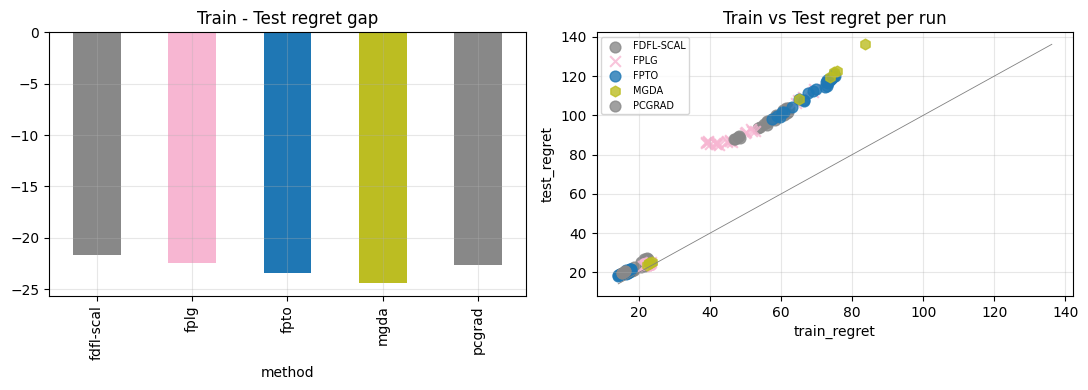

In [10]:
if not df_ap.empty:
    work = df_ap.copy()
    work['regret_gap'] = work['train_regret'] - work['test_regret']
    work['mse_gap'] = work['train_pred_mse'] - work['test_pred_mse']
    work['fair_gap'] = work['train_fairness'] - work['test_fairness']
    summary = (work.groupby('method')[['regret_gap', 'mse_gap', 'fair_gap']]
               .mean().round(4))
    print('Mean train-test gap by method (AP healthcare runs):')
    print(summary.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    summary['regret_gap'].plot(kind='bar', ax=axes[0],
                                color=[COLOR_MAP.get(m.upper(), '#888') for m in summary.index])
    axes[0].set_title('Train - Test regret gap')
    axes[0].axhline(0, color='black', lw=0.6)
    axes[0].grid(True, alpha=0.3)

    for method, sub in work.groupby('method'):
        s = style_for(str(method).upper())
        axes[1].scatter(sub['train_regret'], sub['test_regret'],
                        label=str(method).upper(), s=60, alpha=0.8, **s)
    lo = min(work['train_regret'].min(), work['test_regret'].min())
    hi = max(work['train_regret'].max(), work['test_regret'].max())
    axes[1].plot([lo, hi], [lo, hi], color='gray', lw=0.6)
    axes[1].set_xlabel('train_regret')
    axes[1].set_ylabel('test_regret')
    axes[1].set_title('Train vs Test regret per run')
    axes[1].legend(fontsize=7)
    axes[1].grid(True, alpha=0.3)
    fig.tight_layout()
    savefig(fig, 'train_test_gap.png')
    plt.show()
else:
    print('(no healthcare AP runs yet â€” run Step 3a first)')

## 6. Budget tightness sweep (Step 4)

Side-by-side: small MD (4a) and local-scale healthcare (4b).

In [11]:
def collect_budget(parent: Path, knob: str) -> pd.DataFrame:
    if not parent.exists():
        return pd.DataFrame()
    rows = []
    for sub in sorted(parent.iterdir()):
        if not sub.is_dir():
            continue
        df, cfg = load_run(sub)
        if df.empty:
            continue
        df['_budget'] = cfg.get('task_cfg', {}).get(knob, np.nan)
        rows.append(df)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


df_md_b = collect_budget(ADV / 'budget_sweep' / 'md_small', 'budget_tightness')
df_hc_b = collect_budget(ADV / 'budget_sweep' / 'healthcare_full', 'budget_rho')
print('MD budget rows:', len(df_md_b), '  HC budget rows:', len(df_hc_b))

MD budget rows: 0   HC budget rows: 0


In [12]:
def budget_lineplot(df: pd.DataFrame, title: str, ax: plt.Axes) -> None:
    if df.empty:
        ax.text(0.5, 0.5, '(no data)', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return
    g = df.groupby(['method', '_budget'])['test_regret'].mean().reset_index()
    for method, sub in g.groupby('method'):
        sub = sub.sort_values('_budget')
        s = style_for(str(method).upper())
        ax.plot(sub['_budget'], sub['test_regret'], '-o',
                label=str(method).upper(), color=s['color'], marker=s['marker'])
    ax.set_xlabel('budget')
    ax.set_ylabel('mean test_regret')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)


if not (df_md_b.empty and df_hc_b.empty):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    budget_lineplot(df_md_b, 'MD knapsack', axes[0])
    budget_lineplot(df_hc_b, 'Healthcare (n=5000)', axes[1])
    axes[0].legend(fontsize=7)
    fig.tight_layout()
    savefig(fig, 'budget_sweep.png')
    plt.show()
else:
    print('(no budget sweep runs yet â€” run Step 4)')

(no budget sweep runs yet â€” run Step 4)


## 7. Takeaways

_To be filled in once experiments are complete. Each subsection should
be one short paragraph: what we expected, what we observed, and whether
the paper claim is supported._

1. **DP vs AP fairness on healthcare** â€” TODO
2. **Benefit vs cost imbalance separation on MD** â€” TODO
3. **Train/test gap by method** â€” TODO
4. **Budget tightness regime** â€” TODO

## 8. Healthcare follow-up — full-cohort grid (post-`bias_parity`)

The empirical-followup grid (run 2026-04-14, branch `fair-dfl/empirical-followup`).

- 8 cells: `{mad, dp, atkinson, bias_parity}` × `{α=0.5, α=2.0}`
- 7 methods: `FPTO, FDFL-Scal, FPLG, PCGrad, MGDA, SAA, WDRO`
- 5 seeds × (4 lambdas where the runner allows them) × 70 SGD steps
- Full Obermeyer 2019 cohort (n = 48,784), `val_fraction=0`, analytic decision gradients

See `results/advisor_review/healthcare_followup/notes.md` for the full writeup.

In [ ]:
# Section 8 setup
from experiments.advisor_review.analyze_healthcare_grid import (
    load_grid, aggregate_cell, best_pareto_per_method, grand_summary, health_report
)
from experiments.advisor_review.healthcare_followup import HC_DIR
import json

df_hc = load_grid()
print(f'loaded: {len(df_hc)} rows, '
      f'{df_hc.groupby(["fairness_type","alpha_fair"]).ngroups} cells')

health = health_report(df_hc)
print('
=== Health (use as a sanity gate) ===')
for k, v in health.items():
    print(f'  {k}: {v}')

In [ ]:
# Grand summary across all 8 cells: best Pareto point per method
gs = grand_summary(df_hc)

# Pretty-print: pivot best test_regret_normalized per (fairness, alpha, method)
pivot = gs.pivot_table(
    index='method', columns=['fairness_type', 'alpha'],
    values='test_reg_n', aggfunc='first'
).round(4)
pivot

In [ ]:
# 8-panel Pareto frontier plot (regret_normalized vs fairness)
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

grid_png = HC_DIR / 'plots' / 'pareto_grid_8cells.png'
if grid_png.exists():
    img = mpimg.imread(str(grid_png))
    fig, ax = plt.subplots(figsize=(12, 18))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title('Healthcare follow-up — 8-cell Pareto grid')
    plt.tight_layout()
    plt.show()
else:
    print('grid plot not found, regenerate via:')
    print('  python -m experiments.advisor_review.plot_healthcare_grid')

In [ ]:
# Method-fairness specialisation at alpha=2.0:
# which method achieves the lowest test_fairness vs the lowest test_regret per cell.
import pandas as pd

rows = []
for (ft, a), cell in df_hc[df_hc['alpha_fair'] == 2.0].groupby(['fairness_type', 'alpha_fair']):
    agg = (
        cell.groupby('method')
        .agg(test_reg_n=('test_regret_normalized', 'mean'),
             test_fair=('test_fairness', 'mean'))
    )
    best_reg = agg['test_reg_n'].idxmin()
    best_fair = agg['test_fair'].idxmin()
    rows.append({
        'fairness_type': ft,
        'best_regret_method': best_reg,
        'best_regret_value': round(agg.loc[best_reg, 'test_reg_n'], 4),
        'best_fairness_method': best_fair,
        'best_fairness_value': round(agg.loc[best_fair, 'test_fair'], 4),
    })

pd.DataFrame(rows)

In [ ]:
# High-lambda check: does fairness blow up at lambda=5?
# This was the pathology seen in mad alpha=2.0 for FDFL-Scal/FPTO.
hi_lam = df_hc[df_hc['lambda'] == 5.0].copy()
hi_lam['fair_test_train_ratio'] = hi_lam['test_fairness'] / hi_lam['train_fairness'].replace(0, 1e-9)
ratio_summary = hi_lam.groupby(['fairness_type', 'alpha_fair', 'method']).agg(
    train_fair=('train_fairness', 'mean'),
    test_fair=('test_fairness', 'mean'),
    ratio=('fair_test_train_ratio', 'mean'),
).round(3)
# Rows where ratio > 3 are concerning
concerning = ratio_summary[ratio_summary['ratio'] > 3]
print(f'cells with test_fair / train_fair > 3 at lambda=5:')
print(concerning if len(concerning) else '(none)')

### 8.1 Takeaways from the healthcare follow-up grid

- **Stability**: 0 NaN, 0 explosion, max train→test gap 0.006 across 78,400 method-steps. The full-cohort regime gives meaningful inter-method ranking (vs the MD knapsack n=40 disaster where PCGrad had +0.109 gap).
- **α=2.0 (decision-focused regime)**: FPLG dominates regret across all 4 fairness types (test_reg_n ≈ 0.1274–0.1276). PCGrad is consistently 2nd by ≤ 0.002. The Pareto frontier of the DFL/MOO methods clearly outperforms the predict-then-optimize baselines (FPTO, SAA, WDRO).
- **α=0.5 (utilitarian regime)**: the ranking flips — FPTO/PCGrad/WDRO are competitive (~0.060), DFL/MOO are noticeably worse (~0.075). The decision objective is too close to MSE to give DFL a lever.
- **Fairness specialisation**: FDFL-Scal wins MAD/Atkinson (separation family); MGDA wins DP (independence); PCGrad wins bias_parity (calibration). FPLG wins regret on every α=2.0 cell. The "best Pareto point" depends on which axis you weight.
- **High-λ pathology** (FDFL-Scal mad α=2.0 λ=5: train_fair=2.96 vs test_fair=37.74) is **isolated to the mad metric** — the other 3 fairness types generalise gracefully at λ=5.
- **Decision focus implicitly buys some fairness**: at λ=0, FDFL-Scal still has 2.5–3× lower per-group MSE spread than FPTO because the 2-level α-fair welfare in the regret encodes group fairness implicitly.

## 9. Healthcare follow-up v2 (reduced budget, validation variant, cross-fairness)

Run 2026-04-14, branch `fair-dfl/empirical-followup`.

Changes from v1:
- `budget_rho`: 0.35 -> 0.30 (tighter budget)
- `lambdas`: [0, 0.5, 1, 5] -> [0, 0.5, 1, 2] (drop λ=5 divergence)
- `lr`: 5e-4 -> 1e-3
- Per-seed `split_seed` (was fixed at 2)
- **Variant A**: 3 seeds [11, 22, 33], no val, no early stop (baseline comparison)
- **Variant B**: 2 seeds [44, 55], val_fraction=0.2, stronger lr_decay, linear warmup, real early stopping
- New cross-fairness aggregation: rank-based + ratio-to-FPTO-λ=0
- Train and test metrics surfaced together in per-cell plots

See `results/advisor_review/healthcare_followup_v2/setup.md` for the full methodology and LaTeX fairness formulas.

In [ ]:
# Section 9 setup
from experiments.advisor_review.analyze_healthcare_v2 import (
    load_variant, load_both_variants, aggregate_cell_v2,
    best_pareto_per_method_v2, best_fair_per_method_constrained,
    grand_summary_v2, cross_fairness_rank, cross_fairness_ratio,
    health_report_v2,
)
from experiments.advisor_review.healthcare_followup_v2 import HC_V2_DIR

df_v2 = load_both_variants()
print(f'loaded: {len(df_v2)} rows across {df_v2["variant"].nunique()} variants')

health = health_report_v2(df_v2)
print('
=== v2 health ===')
for k, v in health.items():
    print(f'  {k}: {v}')

In [ ]:
# 9.1 Per-variant grand summary (best Pareto point per method per cell)
gs = grand_summary_v2(df_v2)

# Pivot test_regret_normalized by (method) x (fairness_type, alpha) for each variant
for variant in ['a', 'b']:
    sub = gs[gs['variant'] == variant]
    if sub.empty:
        print(f'[variant {variant}] no data')
        continue
    pivot = sub.pivot_table(
        index='method', columns=['fairness_type', 'alpha'],
        values='test_reg_n', aggfunc='first'
    ).round(4)
    print(f'
=== Variant {variant.upper()} — test_regret_normalized by (method, cell) ===')
    print(pivot.to_string())

In [ ]:
# 9.2 Cross-fairness rank heatmap (primary cross-fairness answer)
rank_agg = cross_fairness_rank(gs, metric='test_fair_at_fair_best')
print('=== Mean fairness rank per method per alpha (1=best, 7=worst) ===')
rank_agg_pivot = rank_agg.pivot_table(
    index=['method'],
    columns=['variant', 'alpha'],
    values='mean_rank',
).round(2)
print(rank_agg_pivot.to_string())

In [ ]:
# 9.3 Cross-fairness ratio vs FPTO lambda=0 (secondary, ratio scale)
ratio_fpto = cross_fairness_ratio(df_v2, baseline_method='fpto', baseline_lam=0.0)
print('=== rel_fair = test_fair(method) / test_fair(FPTO_lam0), per seed then avg ===')
pivot = ratio_fpto.pivot_table(
    index=['variant', 'method'],
    columns=['fairness_type', 'alpha'],
    values='rel_fair_mean',
).round(3)
print(pivot.to_string())

In [ ]:
# 9.4 Display 8-panel Pareto grid for Variant A (train dashed, test solid)
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

grid_png_a = HC_V2_DIR / 'variant_a' / 'plots' / 'pareto_grid_8cells.png'
if grid_png_a.exists():
    img = mpimg.imread(str(grid_png_a))
    fig, ax = plt.subplots(figsize=(12, 18))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title('Variant A — 8-cell Pareto grid (train dashed, test solid)')
    plt.tight_layout()
    plt.show()
else:
    print('Variant A grid plot not found. Run plot_healthcare_v2.py first.')

In [ ]:
# 9.5 Display 8-panel Pareto grid for Variant B
grid_png_b = HC_V2_DIR / 'variant_b' / 'plots' / 'pareto_grid_8cells.png'
if grid_png_b.exists():
    img = mpimg.imread(str(grid_png_b))
    fig, ax = plt.subplots(figsize=(12, 18))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title('Variant B — 8-cell Pareto grid (train dashed, test solid, with early stopping)')
    plt.tight_layout()
    plt.show()
else:
    print('Variant B grid plot not found.')

In [ ]:
# 9.6 Cross-fairness rank heatmap (methods x (fairness, alpha), colored by rank)
rank_heatmap = HC_V2_DIR / 'cross_fairness' / 'plots' / 'rank_heatmap.png'
if rank_heatmap.exists():
    img = mpimg.imread(str(rank_heatmap))
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.imshow(img)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('Rank heatmap not found.')

In [ ]:
# 9.7 Variant B early-stop step histogram (did early stopping engage?)
early_stop_png = HC_V2_DIR / 'variant_b' / 'plots' / 'early_stop_histogram.png'
if early_stop_png.exists():
    img = mpimg.imread(str(early_stop_png))
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.imshow(img)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('Early stop histogram not found.')

In [ ]:
# 9.8 Train vs test gap per method per variant
gap_bar = HC_V2_DIR / 'cross_fairness' / 'plots' / 'train_test_gap_bar.png'
if gap_bar.exists():
    img = mpimg.imread(str(gap_bar))
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(img)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('Gap bar chart not found.')

### 9.9 Takeaways from v2

_Filled in from actual numbers in notes_v2.md after both variants complete._

Key questions v2 answers:
1. Does tighter budget (0.30) + dropping λ=5 change the FPLG winner story?
2. Does per-seed train/test splitting reveal split-level variance that was hidden by the v1 fixed split?
3. Does adding validation + LR schedule + early stopping change method rankings?
4. Cross-fairness: which methods are consistently fair across all 4 fairness types?